# Association Rules - Market Basket Analysis
**Dataset:** Online Retail Dataset  
**Objective:** Apply Apriori algorithm to discover interesting relationships between products purchased together.

## 1. Install Required Libraries

In [1]:
print("Libraries pre-installed.")

Libraries pre-installed.


## 2. Import Libraries

In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('All libraries imported successfully.')

All libraries imported successfully.


## 3. Load the Dataset

In [3]:
# Load the dataset - items are comma-separated within a single column
df_raw = pd.read_excel('Online_retail.xlsx', header=None)

print('Shape:', df_raw.shape)
print()
print('First 5 rows:')
df_raw.head()

Shape: (7501, 1)

First 5 rows:


,0
0,"shrimp,almonds,avocado,vegetables mix,green gr..."
1,"burgers,meatballs,eggs"
2,chutney
3,"turkey,avocado"
4,"mineral water,milk,energy bar,whole wheat rice..."


## 4. Data Preprocessing

In [4]:
# Each row contains comma-separated items in a single column
# Split on comma to extract individual items per transaction
transactions = []

for _, row in df_raw.iterrows():
    val = str(row[0]).strip()
    if val and val.lower() != 'nan':
        items = [item.strip() for item in val.split(',') if item.strip()]
        if len(items) > 0:
            transactions.append(items)

print('Total transactions:', len(transactions))
print()
print('Sample transaction 1:', transactions[0])
print('Sample transaction 2:', transactions[1])
print('Sample transaction 3:', transactions[2])

Total transactions: 7501

Sample transaction 1: ['shrimp', 'almonds', 'avocado', 'vegetables mix', 'green grapes', 'whole weat flour', 'yams', 'cottage cheese', 'energy drink', 'tomato juice', 'low fat yogurt', 'green tea', 'honey', 'salad', 'mineral water', 'salmon', 'antioxydant juice', 'frozen smoothie', 'spinach', 'olive oil']
Sample transaction 2: ['burgers', 'meatballs', 'eggs']
Sample transaction 3: ['chutney']


In [5]:
# Check for any duplicate transactions
transactions_tuples = [tuple(sorted(t)) for t in transactions]
unique_count = len(set(transactions_tuples))
print('Total transactions     :', len(transactions))
print('Unique transactions    :', unique_count)
print('Duplicate transactions :', len(transactions) - unique_count)

Total transactions     : 7501
Unique transactions    : 5154
Duplicate transactions : 2347


In [6]:
# Get all unique items
all_items = [item for transaction in transactions for item in transaction]
unique_items = list(set(all_items))

print('Total item occurrences :', len(all_items))
print('Unique items           :', len(unique_items))

# Top 15 most frequent items
item_freq = pd.Series(all_items).value_counts().head(15)
print()
print('Top 15 Most Frequent Items:')
print(item_freq.to_string())

Total item occurrences : 29363
Unique items           : 119

Top 15 Most Frequent Items:
mineral water        1788
eggs                 1348
spaghetti            1306
french fries         1282
chocolate            1230
green tea             991
milk                  972
ground beef           737
frozen vegetables     715
pancakes              713
burgers               654
cake                  608
cookies               603
escalope              595
low fat yogurt        574


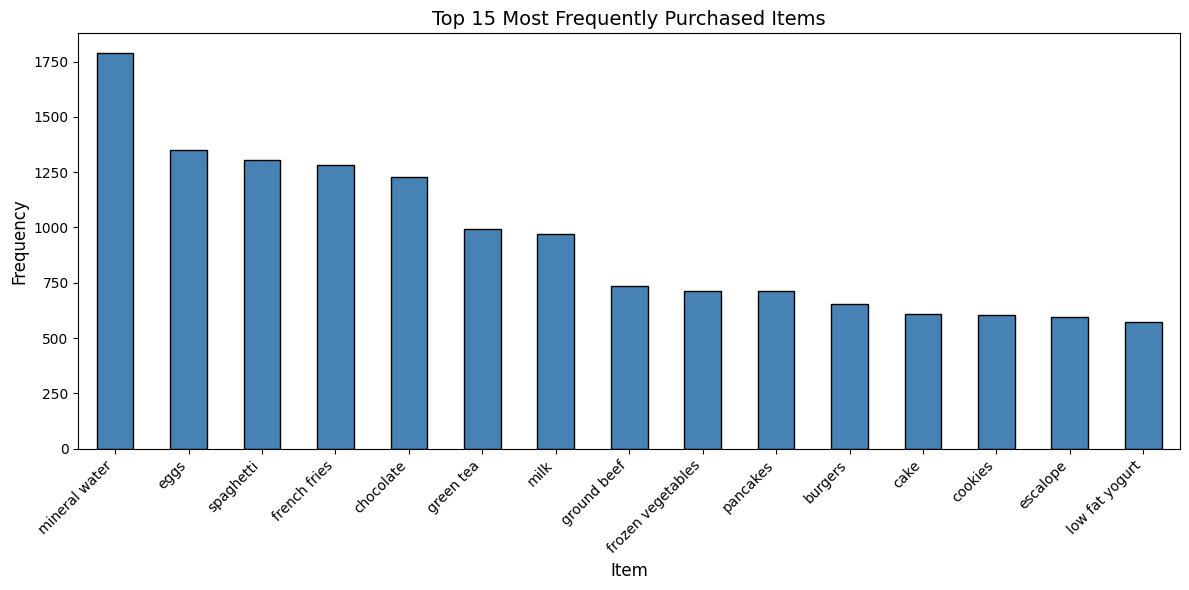

In [7]:
# Visualize top 15 most frequent items
plt.figure(figsize=(12, 6))
item_freq.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 15 Most Frequently Purchased Items', fontsize=14)
plt.xlabel('Item', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Encode Transactions (One-Hot Encoding)

In [8]:
# Use TransactionEncoder to convert list of transactions into a one-hot encoded dataframe
# Each column = one item, each row = one transaction
# True = item was purchased in that transaction, False = not purchased

te = TransactionEncoder()
te_array = te.fit_transform(transactions)

# Convert to DataFrame
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print('Encoded DataFrame shape:', df_encoded.shape)
print()
print('First 5 rows (first 8 columns):')
df_encoded.iloc[:5, :8]

Encoded DataFrame shape: (7501, 119)

First 5 rows (first 8 columns):


,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea
0,True,True,False,True,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False
4,False,False,False,False,False,False,False,False


## 6. Apply Apriori Algorithm

In [9]:
# Apply Apriori Algorithm
# min_support = 0.03 means the itemset must appear in at least 3% of all transactions
# use_colnames=True keeps item names instead of column indices

frequent_itemsets = apriori(
    df_encoded,
    min_support=0.03,
    use_colnames=True
)

# Add a column showing the length of each itemset
frequent_itemsets['itemset_length'] = frequent_itemsets['itemsets'].apply(len)

print('Total frequent itemsets found:', len(frequent_itemsets))
print()
print('Itemset size distribution:')
print(frequent_itemsets['itemset_length'].value_counts().sort_index().to_string())
print()
print('Top 10 Frequent Itemsets by Support:')
frequent_itemsets.sort_values('support', ascending=False).head(10)

Total frequent itemsets found: 54

Itemset size distribution:
itemset_length
1    36
2    18

Top 10 Frequent Itemsets by Support:


,support,itemsets,itemset_length
25,0.2384,frozenset({mineral water}),1
11,0.1797,frozenset({eggs}),1
31,0.1741,frozenset({spaghetti}),1
13,0.1709,frozenset({french fries}),1
7,0.1638,frozenset({chocolate}),1
18,0.1321,frozenset({green tea}),1
24,0.1296,frozenset({milk}),1
19,0.0983,frozenset({ground beef}),1
16,0.0953,frozenset({frozen vegetables}),1
27,0.0951,frozenset({pancakes}),1


## 7. Generate Association Rules

In [10]:
# Generate Association Rules
# min_threshold=0.3 for confidence means: given antecedent is bought, consequent is bought 30%+ of the time

rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.3
)

# Display key columns
rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

print('Total rules generated:', len(rules))
print()
print('First 10 rules:')
rules.head(10)

Total rules generated: 7

First 10 rules:


,antecedents,consequents,support,confidence,lift
0,frozenset({chocolate}),frozenset({mineral water}),0.0527,0.3214,1.3483
1,frozenset({frozen vegetables}),frozenset({mineral water}),0.0357,0.3748,1.5725
2,frozenset({ground beef}),frozenset({mineral water}),0.0409,0.4166,1.7475
3,frozenset({ground beef}),frozenset({spaghetti}),0.0392,0.3989,2.2912
4,frozenset({milk}),frozenset({mineral water}),0.0480,0.3704,1.5538
5,frozenset({pancakes}),frozenset({mineral water}),0.0337,0.3548,1.4886
6,frozenset({spaghetti}),frozenset({mineral water}),0.0597,0.3430,1.4391


## 8. Filter Strong Rules (High Lift)

In [11]:
# Filter rules where lift > 1.2 (indicates a meaningful positive association)
# Sorted by lift in descending order to see the strongest relationships first

strong_rules = rules[rules['lift'] > 1.2].sort_values('lift', ascending=False)

print('Strong rules (lift > 1.2):', len(strong_rules))
print()
print('Top 15 Strong Rules:')
strong_rules.head(15)

Strong rules (lift > 1.2): 7

Top 15 Strong Rules:


,antecedents,consequents,support,confidence,lift
3,frozenset({ground beef}),frozenset({spaghetti}),0.0392,0.3989,2.2912
2,frozenset({ground beef}),frozenset({mineral water}),0.0409,0.4166,1.7475
1,frozenset({frozen vegetables}),frozenset({mineral water}),0.0357,0.3748,1.5725
4,frozenset({milk}),frozenset({mineral water}),0.0480,0.3704,1.5538
5,frozenset({pancakes}),frozenset({mineral water}),0.0337,0.3548,1.4886
6,frozenset({spaghetti}),frozenset({mineral water}),0.0597,0.3430,1.4391
0,frozenset({chocolate}),frozenset({mineral water}),0.0527,0.3214,1.3483


## 9. Analysis and Visualizations

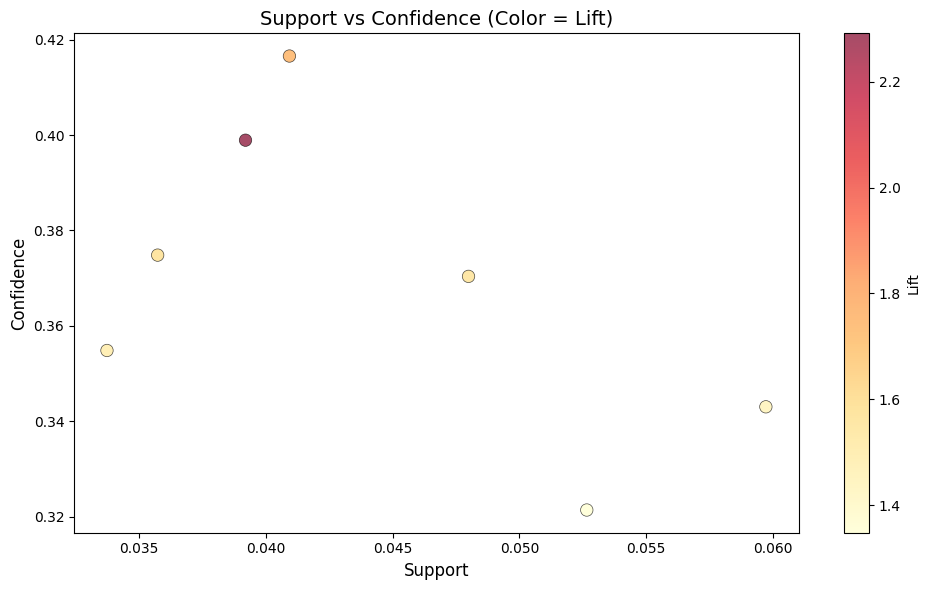

In [12]:
# Scatter plot: Support vs Confidence, color-coded by Lift
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    rules['support'],
    rules['confidence'],
    c=rules['lift'],
    cmap='YlOrRd',
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5,
    s=80
)
plt.colorbar(scatter, label='Lift')
plt.title('Support vs Confidence (Color = Lift)', fontsize=14)
plt.xlabel('Support', fontsize=12)
plt.ylabel('Confidence', fontsize=12)
plt.tight_layout()
plt.show()

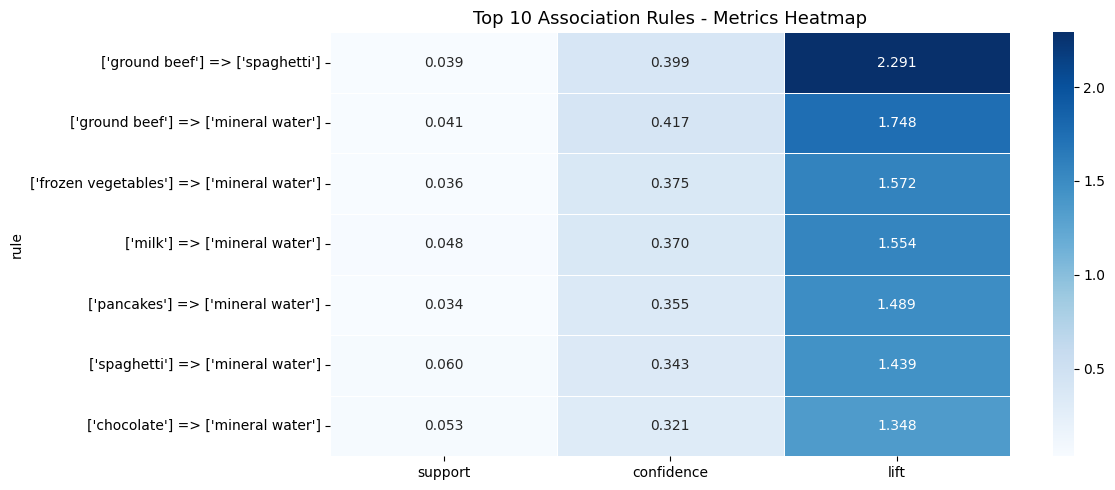

In [13]:
# Heatmap of Lift for top 10 rules
top10 = strong_rules.head(10).copy()
top10['rule'] = [
    str(list(a)) + ' => ' + str(list(c))
    for a, c in zip(top10['antecedents'], top10['consequents'])
]

plt.figure(figsize=(12, 5))
pivot_data = top10[['rule', 'support', 'confidence', 'lift']].set_index('rule')
sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='Blues', linewidths=0.5)
plt.title('Top 10 Association Rules - Metrics Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

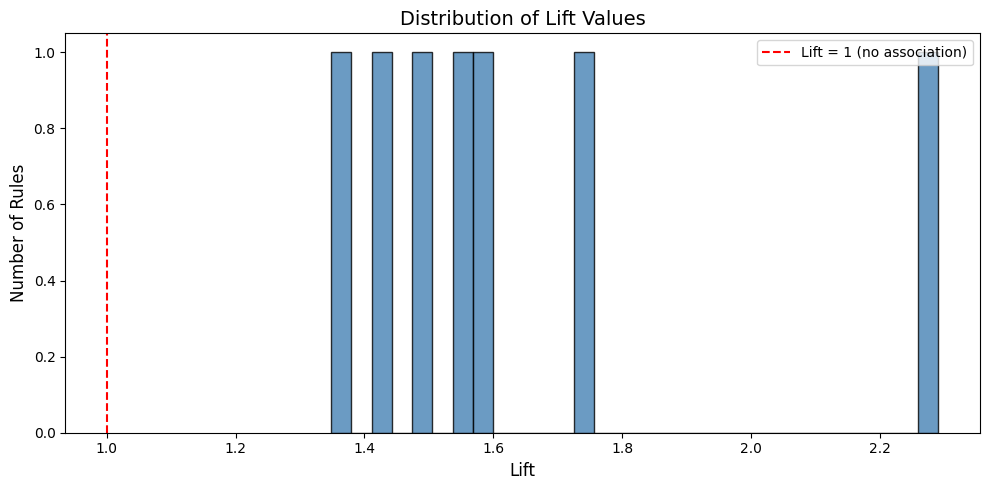

In [14]:
# Distribution of Lift values across all rules
plt.figure(figsize=(10, 5))
plt.hist(rules['lift'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(x=1.0, color='red', linestyle='--', linewidth=1.5, label='Lift = 1 (no association)')
plt.title('Distribution of Lift Values', fontsize=14)
plt.xlabel('Lift', fontsize=12)
plt.ylabel('Number of Rules', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

## 10. Interpretation and Insights

In [15]:
# Summary statistics of the generated rules
print('Summary Statistics of All Rules:')
print(rules[['support', 'confidence', 'lift']].describe().to_string())

print()
print('Rule with Highest Lift:')
best_rule = rules.loc[rules['lift'].idxmax()]
print('  Antecedent  :', set(best_rule['antecedents']))
print('  Consequent  :', set(best_rule['consequents']))
print('  Support     :', round(best_rule['support'], 4))
print('  Confidence  :', round(best_rule['confidence'], 4))
print('  Lift        :', round(best_rule['lift'], 4))

print()
print('Rule with Highest Confidence:')
best_conf = rules.loc[rules['confidence'].idxmax()]
print('  Antecedent  :', set(best_conf['antecedents']))
print('  Consequent  :', set(best_conf['consequents']))
print('  Support     :', round(best_conf['support'], 4))
print('  Confidence  :', round(best_conf['confidence'], 4))
print('  Lift        :', round(best_conf['lift'], 4))

Summary Statistics of All Rules:
       support  confidence   lift
count   7.0000      7.0000 7.0000
mean    0.0443      0.3686 1.6344
std     0.0095      0.0325 0.3151
min     0.0337      0.3214 1.3483
25%     0.0375      0.3489 1.4639
50%     0.0409      0.3704 1.5538
75%     0.0503      0.3869 1.6600
max     0.0597      0.4166 2.2912

Rule with Highest Lift:
  Antecedent  : {'ground beef'}
  Consequent  : {'spaghetti'}
  Support     : 0.0392
  Confidence  : 0.3989
  Lift        : 2.2912

Rule with Highest Confidence:
  Antecedent  : {'ground beef'}
  Consequent  : {'mineral water'}
  Support     : 0.0409
  Confidence  : 0.4166
  Lift        : 1.7475


In [16]:
# Business Insight: Rules with lift > 1 indicate items bought together more than by chance
positive_lift = rules[rules['lift'] > 1]
negative_lift = rules[rules['lift'] < 1]
neutral_lift  = rules[rules['lift'] == 1]

print('Lift Interpretation Summary:')
print('  Rules with Lift > 1 (positive association) :', len(positive_lift))
print('  Rules with Lift = 1 (no association)       :', len(neutral_lift))
print('  Rules with Lift < 1 (negative association) :', len(negative_lift))
print()
print('Insight: Items appearing in rules with lift > 1 are purchased together')
print('more frequently than expected by chance, making them good candidates')
print('for product bundling, cross-selling, or shelf placement strategies.')

Lift Interpretation Summary:
  Rules with Lift > 1 (positive association) : 7
  Rules with Lift = 1 (no association)       : 0
  Rules with Lift < 1 (negative association) : 0

Insight: Items appearing in rules with lift > 1 are purchased together
more frequently than expected by chance, making them good candidates
for product bundling, cross-selling, or shelf placement strategies.


## 11. Interview Questions and Answers

### Q1. What is Lift and why is it important in Association Rules?

**Lift** measures how much more likely item B is purchased when item A is purchased, compared to the baseline probability of purchasing B alone.

**Formula:**

    Lift(A => B) = Confidence(A => B) / Support(B)
                = P(A and B) / (P(A) * P(B))

**Interpretation:**
- Lift > 1 : A and B are purchased together more than by chance (positive association)
- Lift = 1 : A and B are independent, no meaningful association
- Lift < 1 : A and B are purchased together less than expected (negative association)

**Why it is important:**
- Support and confidence alone can be misleading. A high-confidence rule can still be useless if the consequent is already very popular on its own.
- Lift corrects for this by comparing against the baseline frequency.
- A lift of 2.5 means the two items appear together 2.5 times more often than expected if they were independent.
- It helps identify genuinely meaningful rules rather than coincidental ones.

### Q2. What is Support and Confidence? How do you calculate them?

**Support:**
Support of an itemset {A, B} is the fraction of all transactions that contain both A and B.

    Support(A => B) = Number of transactions containing A and B / Total transactions
                   = P(A and B)

Example: If mineral water and eggs appear together in 150 out of 1000 transactions:

    Support = 150 / 1000 = 0.15  (15%)

Support tells you how frequently an itemset appears in the dataset. Low support means the rule applies to very few customers.

---

**Confidence:**
Confidence of a rule A => B is the probability that a transaction containing A also contains B.

    Confidence(A => B) = Support(A and B) / Support(A)
                       = P(A and B) / P(A)

Example: If 150 transactions contain both mineral water and eggs, and 300 transactions contain mineral water:

    Confidence = 150 / 300 = 0.50  (50%)

Confidence tells you: out of all customers who bought A, what percentage also bought B. Higher confidence indicates a stronger rule.

### Q3. What are some limitations or challenges of Association Rule Mining?

**1. Large number of rules generated**
Even with modest datasets, thousands of rules can be generated. Many of these may be trivial, redundant, or not actionable. Manual interpretation becomes difficult.

**2. Choosing thresholds is subjective**
The choice of minimum support, confidence, and lift thresholds strongly affects results. Setting them too high misses weak but valuable patterns. Setting them too low floods the output with useless rules. There is no universal optimal value.

**3. Computational cost**
The Apriori algorithm generates candidate itemsets iteratively and requires multiple passes over the dataset. For very large datasets with many unique items, this becomes computationally expensive and slow.

**4. Rules capture correlation, not causation**
A rule A => B only means A and B co-occur frequently. It does not mean buying A causes someone to buy B. Decisions based on rules alone can be misleading without further analysis.

**5. Rare but important items are missed**
Items with naturally low frequency (expensive products, seasonal items) are filtered out by the minimum support threshold even if they have strong associations. This is called the rare item problem.

**6. Sensitive to data quality**
Missing values, duplicate transactions, or inconsistent item naming can significantly distort the rules and lead to incorrect conclusions.

**7. No temporal or sequential context**
Basic association rules treat all transactions as independent snapshots. They do not capture the order or timing of purchases (e.g., a customer buys a printer first and then ink cartridges later).